# Causal Entropic Forces

Here's how the algorithm works:
1. From the current state, sample `NUM_ROLLOUTS`
2. Estimate the probability of sampling trajectory i `p(traj_i)` using kernel density estimation
3. Define the volume of trajectory i as `vol_i = 1 / p(traj_i)`
4. Calculate the normalized volume of a trajectory `norm_vol_i = vol_i / \sum_i vol_i`
5. Calculate the causal entropic force `2 * T_C / T_R \mean_i f_i * \log norm_vol_i`, where `f_i` is the initial force of trajectory i and the value `T_C / T_R` governs how much more you want to exploit (acting following the entropic force) vs explore (sampling a trajectory)
6. Use the causal entropic force to update the current state

In [1]:
import numpy as np

import scipy

from matplotlib import pyplot as plt
from matplotlib import patches as patches
from matplotlib import cm

import copy
import time
import datetime

In [2]:
np.random.seed(0)

dtype = np.float32

## Hyperparameters

In [3]:
T_R     = 4e5  # temperature of random agent (K)
T_C     = 2e6  # temperature of causal agent (K)
TAU     = 10.  # simulation time horizon (seconds)
EPSILON = .025 # timesteps (seconds)

In [4]:
NUM_ROLLOUTS = 100

In [5]:
NUM_SUBSAMPLES = 3

In [6]:
CHUNK_SIZE = 5000

## Particle-in-a-box environment and dynamics

In [7]:
M     = 1e-21                             # mass (kg)
L     = 400                               # length (meters) 
Q_MIN = np.array([0., 0.  ], dtype=dtype) # minimum box displacements
Q_MAX = np.array([L , L/5.], dtype=dtype) # maximum box displacements

In [8]:
def step_p(p, f):
    p     = f * EPSILON
    p_max = M * np.abs(Q_MAX - Q_MIN) / EPSILON
    new_p = np.sign(p) * np.minimum(p_max, np.abs(p))
    return new_p

In [9]:
def step_q(q, p, new_p):
    new_q = q  +  .5 * EPSILON * (p + new_p) / M
    return new_q

In [10]:
def enforce_elastic_collisions(p, q):
    q  = np.maximum(q, 2 * Q_MIN - q)
    p *= np.sign(q - Q_MIN)
    q  = np.minimum(q, 2 * Q_MAX - q)
    p *= np.sign(Q_MAX - q)
    return p, q

In [11]:
def step_phase_space(p, q, f):
    new_p        = step_p(p, f)
    new_q        = step_q(q, p, new_p)
    new_p, new_q = enforce_elastic_collisions(new_p, new_q)
    return new_p, new_q

## Random rollouts

In [12]:
timesteps = int(TAU / EPSILON)

In [13]:
def generate_fs(num_samples):
    # scale calculation formula from https://math.stackexchange.com/a/1426406
    return np.random.normal( loc   = 0. ,
                             scale = np.sqrt(M * scipy.constants.Boltzmann * T_R) / EPSILON ,
                             size  = (num_samples, 2) ).astype(dtype)

In [14]:
def rollouts(p, q, num_samples):
    """
    paths.shape = (timesteps, num_samples, q_dim)
    """
    ps = np.tile(p[None, :], (num_samples, 1))
    qs = np.tile(q[None, :], (num_samples, 1))

    paths = copy.deepcopy(qs[None, :])

    fs       = generate_fs(num_samples)
    first_fs = copy.deepcopy(fs)
    
    for i in range(timesteps):
        ps, qs = step_phase_space(ps, qs, fs)
        paths  = np.append(paths, qs[None, :], axis=0)
        fs     = generate_fs(num_samples)

    return paths, first_fs

## Causal Entropic Forcing

In [15]:
def subsample(paths):
    # idea and code from Google Gemini to speed up KDE
    sub_indices = np.linspace( 0 ,
                               timesteps - 1 ,
                               NUM_SUBSAMPLES ,
                               dtype=np.int32 ) 
    sub_paths = paths[sub_indices, :, :]
    return sub_paths

In [16]:
# The following code is modified from 
# [1]: https://github.com/scipy/scipy/blob/main/scipy/stats/_kde.py
# [2]: https://github.com/scipy/scipy/blob/main/scipy/stats/_stats.pyx#L744
# [3]: code generated by Google Gemini Flash 3.6 to implement gaussian kde
# with diagonal bandwidth matrix (the idea to use a diagonal kernel was also
# suggested by Google Gemini Flash 3.6)
# 
# [1] has a copyright notice which I have reproduced below
# 
# -------------------------------------------------------------------------------
#
#  Define classes for (uni/multi)-variate kernel density estimation.
#
#  Currently, only Gaussian kernels are implemented.
#
#  Written by: Robert Kern
#
#  Date: 2004-08-09
#
#  Modified: 2005-02-10 by Robert Kern.
#              Contributed to SciPy
#            2005-10-07 by Robert Kern.
#              Some fixes to match the new scipy_core
#
#  Copyright 2004-2005 by Enthought, Inc.
#
# -------------------------------------------------------------------------------


def diag_gaussian_kde_logpdfs(dataset, subsampling=True, chunk_size=CHUNK_SIZE):
    d, m = dataset.shape
    
    std_per_dim = np.std(dataset, axis=1, keepdims=True)
    scotts_factor = np.power(m, -1. / (d + 4))
    diag_bandwidth = std_per_dim * scotts_factor  # shape (d, 1)
    dataset_ = (dataset / diag_bandwidth).T.astype(dtype)

    # all in one go
    # arg = np.sum((dataset_ - dataset_[:, None]) ** 2., axis=-1)
    # log_pdfs = scipy.special.logsumexp(-arg/2., axis=1)
    
    # naive loop
    log_pdfs = np.zeros(m)
    for j in range(m):
        arg = np.sum((dataset_ - dataset_[j, :]) ** 2., axis=-1)
        log_pdfs[j] = scipy.special.logsumexp(-arg/2.)

    # chunking
    # log_pdfs = np.zeros(m)
    # for j in range(0, m, chunk_size):
    #     arg = np.sum((dataset_ - dataset_[j : j+chunk_size][:, None]) ** 2., axis=-1)
    #     log_pdfs[j : j+chunk_size] = scipy.special.logsumexp(-arg/2., axis=1)

    # scipy function
    # arg = scipy.spatial.distance.cdist(dataset_, dataset_, 'sqeuclidean')
    # log_pdfs = scipy.special.logsumexp(-arg/2., axis=1)

    return log_pdfs

In [17]:
def log_vol_fracs(dataset, subsampling=True):
    if subsampling:
        dataset = subsample(dataset[1:])
    dataset = dataset.transpose((2, 0, 1)).reshape(-1, NUM_ROLLOUTS).astype(dtype)
    
    log_pdfs = diag_gaussian_kde_logpdfs(dataset)
    log_omega = -log_pdfs
    log_volume_fracs = log_omega - scipy.special.logsumexp(log_omega)
    return log_volume_fracs

In [18]:
def entropic_force(p, q):
    paths, fs = rollouts(p, q, NUM_ROLLOUTS)
    return np.mean( fs * log_vol_fracs(paths)[:, None] , axis=0 )

## Rollouts

In [19]:
import jax

from jax import numpy as jnp

def diag_gaussian_kde_logpdfs_jax(dataset, subsampling=True, chunk_size=CHUNK_SIZE):
    d, m = dataset.shape
    
    std_per_dim = jnp.std(dataset, axis=1, keepdims=True)
    scotts_factor = jnp.power(m, -1. / (d + 4))
    diag_bandwidth = std_per_dim * scotts_factor  # shape (d, 1)
    dataset_ = (dataset / diag_bandwidth).T

    log_pdfs = jnp.zeros(m)
    for j in range(0, m, chunk_size):
        arg = jnp.sum((dataset_ - dataset_[j : j+chunk_size][:, None]) ** 2., axis=-1)
        log_pdfs = log_pdfs.at[j : j+chunk_size].set(jax.scipy.special.logsumexp(-arg/2., axis=1))
    
    return log_pdfs

In [20]:
p = np.array([0.   , 0.   ])
q = np.array([L/10., L/10.])

In [21]:
paths, fs = rollouts(p, q, NUM_ROLLOUTS)
paths = subsample(paths[1:])
flat_paths = paths.transpose((2, 0, 1)).reshape(-1, NUM_ROLLOUTS).astype(dtype)

In [26]:
diag_gaussian_kde_logpdfs_jax(flat_paths) - diag_gaussian_kde_logpdfs(flat_paths)

Array([ 5.9604645e-08,  5.9604645e-08,  2.4586916e-07,  3.5762787e-07,
        4.7683716e-07,  5.9604645e-07,  4.7683716e-07, -5.3644180e-07,
       -3.9488077e-07, -9.6857548e-08, -5.9604645e-08, -5.9604645e-08,
       -4.7683716e-07,  4.7683716e-07, -5.4016709e-07, -1.1920929e-07,
       -2.3841858e-06,  1.0430813e-07, -2.6822090e-07,  8.9406967e-07,
        0.0000000e+00, -8.3446503e-07,  2.3841858e-07, -1.8179417e-06,
        1.7881393e-07,  1.1269003e-07, -3.8743019e-07, -5.9604645e-08,
       -6.2584877e-07,  1.1324883e-06,  1.4901161e-06,  1.0132790e-06,
       -1.1622906e-06, -4.1723251e-07,  8.0466270e-07,  7.4505806e-07,
        1.3411045e-06, -8.3446503e-07, -1.8626451e-07,  5.9604645e-07,
        7.7486038e-07,  1.6391277e-07, -1.2516975e-06,  5.5879354e-08,
       -1.7285347e-06,  3.7252903e-09,  2.6822090e-07,  8.9406967e-07,
       -7.1525574e-07, -1.2367964e-06,  1.0132790e-06,  2.9802322e-08,
       -2.9802322e-08,  1.1622906e-06, -5.9604645e-07, -2.9802322e-07,
      

In [24]:
p = np.array([0.   , 0.   ])
q = np.array([L/10., L/10.])

path = copy.deepcopy(q[None, :])

start_time = time.time()
for timestep in range(100):
    elapsed_time = time.time() - start_time
    print(timestep, datetime.timedelta(seconds=int(elapsed_time)), q)
    
    f_c  = 2. * T_C / T_R * entropic_force(p, q)
    p, q = step_phase_space(p, q, f_c)
    path = np.append(path, q[None, :], axis=0)

0 0:00:00 [40. 40.]
1 0:00:00 [45.66271644 47.04627713]
2 0:00:00 [48.33415908 53.97999514]
3 0:00:00 [47.67764501 59.36324043]
4 0:00:00 [48.6511884  70.82555862]
5 0:00:00 [49.51666835 79.23988452]
6 0:00:00 [57.94419224 79.82102334]
7 0:00:00 [69.39860567 79.168439  ]
8 0:00:00 [75.82716362 71.07607117]
9 0:00:00 [76.77997236 56.59795015]
10 0:00:00 [75.2927413  48.86947069]
11 0:00:00 [75.70405571 37.28317337]
12 0:00:00 [75.7154543  26.16951025]
13 0:00:00 [73.89435586 22.99665728]
14 0:00:00 [75.91161812 21.25873041]
15 0:00:00 [81.63723354 18.59902599]
16 0:00:00 [83.17180098 25.42313247]
17 0:00:00 [77.57371044 31.57534039]
18 0:00:00 [70.73638046 31.47727829]
19 0:00:00 [68.76971061 33.53216629]
20 0:00:00 [69.53145736 31.60302164]
21 0:00:00 [69.24484471 32.38923908]
22 0:00:00 [67.24755582 33.83203977]
23 0:00:00 [66.25417416 29.71356577]
24 0:00:00 [69.58672418 27.98222252]
25 0:00:00 [71.54919419 27.578476  ]
26 0:00:00 [71.51231882 24.18286669]
27 0:00:00 [75.66407165 25.

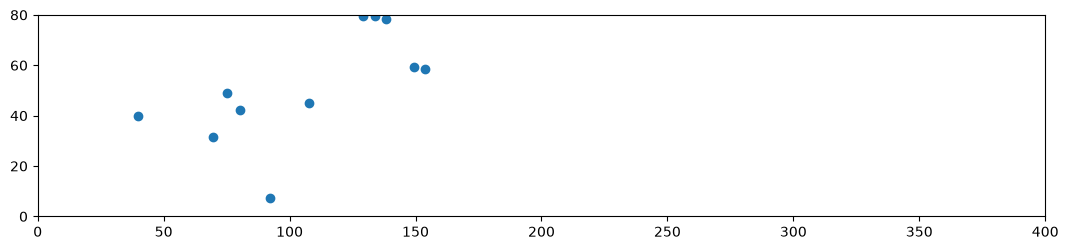

In [25]:
fig, ax = plt.subplots(figsize=(13, 13))
ax.scatter(*path[::10].T)
ax.set_xlim(Q_MIN[0], Q_MAX[0])
ax.set_ylim(Q_MIN[1], Q_MAX[1])
ax.set(aspect='equal')
plt.show()